## Лабораторная работа. Подрисовка изображений

### Прудникова Анастасия 214

#### $\S$ 1. Подрисовка изображений. Постановка задачи.

Под изображением будем понимать вектор $f\in \mathbf{R}^s$. Целью будет нахождение неизвестного изображения $u\in \mathbf{R}^s$ по наблюдаемому изображению $f$. Пусть $\Omega = \{1,2,\dots, s\}$ и $\Lambda \subset \Omega$. Наблюдаемое изображение имеет вид:

$$
f_i = \begin{cases}u_i + \eta_i,~~~i\in\Lambda;\\ \text{проивольно}, ~~~ i\in \Omega\setminus \Lambda.\end{cases}
$$

Задача восстановления неизвестного изображения $u$ относится к задаче аппроксимации. Обозначим $\mathrm{P}_{\Lambda}$ диагональную матрицу, у которой $(\mathrm{P}_{\Lambda})_{i,i} = 1,~~\forall i\in \Lambda$ и $(\mathrm{P}_{\Lambda})_{i,i} = 0,~~\forall i\in \Omega\setminus\Lambda$. Кроме того, введем еще следующие обозначения: $W:~f\to Wf$ -- дискретное вейвлет-преобразование (вейвлет-восстановление), ставящее в соответствие данному вектору вейвлет-коэффициентов $\beta\in\mathbf{R}^d$ изображение $f = W\beta\in\mathbf{R}^s$ и $W^{-1}$ -- обратное преобразование. Пусть

$$
\Gamma_{\lambda}(\beta_1,\dots,\beta_d) = \begin{pmatrix}t_{\lambda_1}(\beta_1) & \dots & t_{\lambda_d}(\beta_d)\end{pmatrix},
$$

где

$$
t_{\lambda_i}(\beta_i) = \begin{cases}\mathrm{sign}(\beta_i)(|\beta_i| - \lambda_i),~~~|\beta_i|>\lambda_i,\\ 0,~~~|\beta_i|\leqslant \lambda_i.\end{cases}
$$

Изображение $u$ будем находить из следующей задачи минимизации:

$$
u = W \beta^*;
$$

$$
\beta^* = \min_{\beta\in\mathbf{R}^d} \frac{1}{2}\|\mathbf{P}_{\Lambda}W\beta - \mathbf{P}_{\Lambda}f\|_2^2 + \mu\|\beta\|_1.
$$

**Алгоритм решения оптимизационной задачи**

1. Выберем произвольный вектор $\beta_0\in\mathbf{R}^d$

2. Находим $\beta_{k+1} = \Gamma_{\mu}\left(W\mathrm{P}_{\Lambda}f + \beta_k - W\mathrm{P}_{\Lambda} W^{-1} \beta_k\right)$, $k=0,1,\dots$

#### Литература

1. J.F. Cai, R.H. Chan, and Z. Shen,A framelet-based image inpainting algorithm, Applied and Computational Harmonic Analysis24(2008), no. 2, 131–149.

In [31]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pywt
%matplotlib inline

(320, 252)


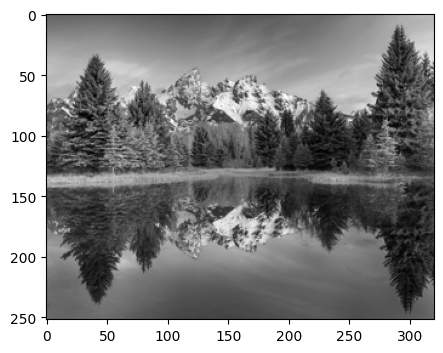

In [55]:
f = Image.open('im_7.jpg').convert('L')
f = f.resize((320, 252))
print(f.size)
fig = plt.figure(figsize = (5,5))
plt.imshow(f, cmap='gray')

In [56]:
coeffs = pywt.wavedecn(f, wavelet = 'db4', level = 2)
arr, coeff_slices = pywt.coeffs_to_array(coeffs)
coeffs_from_arr = pywt.array_to_coeffs(arr, coeff_slices, output_format = 'wavedecn')
I = pywt.waverecn(coeffs_from_arr, wavelet = 'db4')
print(np.max(np.abs(f - I)))

2.2737367544323206e-13


In [57]:
''' Здесь создаем то, что будем закрашивать. Удалять будем линии '''
P_Lambda = np.zeros((np.array(f).shape)) + 1
x0 = np.int64(np.array(f).shape[0] / 2)
y0 = np.int64(np.array(f).shape[1] / 2)
N = 1000
for i in range(N):
    x = np.int64(x0 + 100 * ((np.cos(2 * np.pi * i / N)) ** 3))
    y = np.int64(y0 + 100 * ((np.sin(2 * np.pi * i / N)) ** 3))
    P_Lambda[x-3:x, y-3:y] = 0

(252, 320)


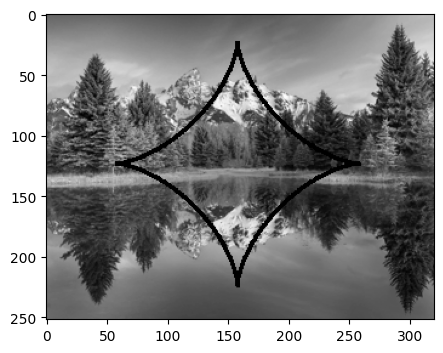

In [58]:
Pf = P_Lambda * np.array(f)
fig = plt.figure(figsize = (5,5))
plt.imshow(Pf, cmap='gray')
print(Pf.shape)

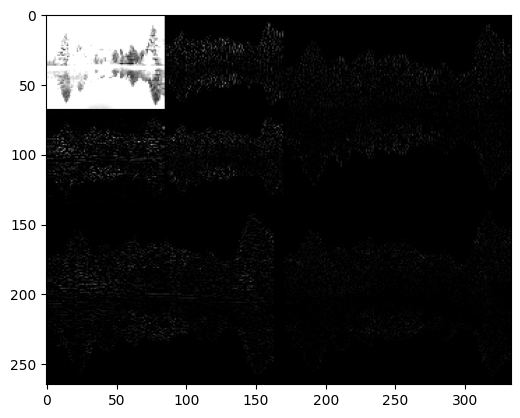

In [59]:
plt.imshow(Image.fromarray(arr))

**Алгоритм решения оптимизационной задачи**

$$
\beta^* = \min_{\beta\in\mathbf{R}^d} \frac{1}{2}\|\mathbf{P}_{\Lambda}W\beta - \mathbf{P}_{\Lambda}f\|_2^2 + \mu\|\beta\|_1.
$$

1. Выберем произвольный вектор $\beta_0\in\mathbf{R}^d$

2. Находим $\beta_{k+1} = \Gamma_{\mu}\left(W\mathrm{P}_{\Lambda}f + \beta_k - W\mathrm{P}_{\Lambda} W^{-1} \beta_k\right)$, $k=0,1,\dots$

In [60]:
def Gamma(A, lamb):
    B = np.abs(A) - lamb
    B[np.nonzero(B <= 0)] = 0
    B = np.sign(A) * B
    return B


def Bregman_Lin(Pf, P_Lambda, Epoch, mu, Level, wavelet):
    beta_k = pywt.wavedecn(Pf, wavelet=wavelet, level=Level)
    arr_beta_k, coeff_slices_beta_k = pywt.coeffs_to_array(beta_k)
    beta_k = arr_beta_k.flatten()

    coeffs_P_Lambda = pywt.wavedecn(P_Lambda, wavelet=wavelet, level=Level)
    arr_P_Lambda, coeff_slices_P_Lambda = pywt.coeffs_to_array(coeffs_P_Lambda)
    P_Lambda_wavelet = arr_P_Lambda.flatten()

    coeffs_Pf = pywt.wavedecn(Pf, wavelet=wavelet, level=Level)
    arr_Pf, coeff_slices_Pf = pywt.coeffs_to_array(coeffs_Pf)
    Pf_wavelet = arr_Pf.flatten()

    def W(beta, coeff_slices, output_format):
        arr_beta = beta.reshape(arr_beta_k.shape)
        coeffs = pywt.array_to_coeffs(arr_beta, coeff_slices, output_format=output_format)
        return pywt.waverecn(coeffs, wavelet=wavelet)

    def W_inv(f):
        coeffs = pywt.wavedecn(f, wavelet=wavelet, level=Level)
        arr, coeff_slices = pywt.coeffs_to_array(coeffs)
        return arr.flatten(), coeff_slices, 'wavedecn'

    for k in range(Epoch):
        Wbeta_k = W(beta_k, coeff_slices_beta_k, 'wavedecn')
        P_Lambda_Wbeta_k = P_Lambda * Wbeta_k
        W_inv_P_Lambda_Wbeta_k, _, _ = W_inv(P_Lambda_Wbeta_k)

        W_P_Lambda_f, _, _ = W_inv(P_Lambda * Pf)

        beta_k_reshaped = beta_k.reshape(arr_beta_k.shape)
        arg = W_P_Lambda_f + beta_k - W_inv_P_Lambda_Wbeta_k
        beta_k = Gamma(arg, mu)

    u = W(beta_k, coeff_slices_beta_k, 'wavedecn')
    return u

In [61]:
Epoch = 100
mu = 6
delta = 0.01
Level = 4
wavelet = 'db4'
u = Bregman_Lin(Pf, P_Lambda, Epoch, mu, Level, wavelet)

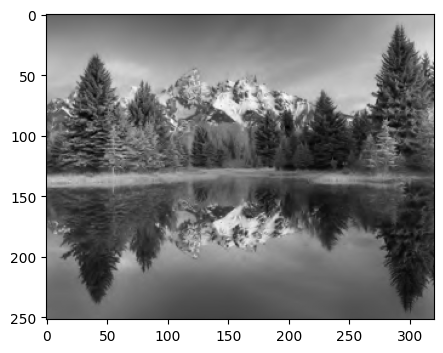

In [62]:
fig = plt.figure(figsize = (5,5))
plt.imshow(u, cmap='gray')

#### $\S$ 2. Удаление текста

(420, 262)


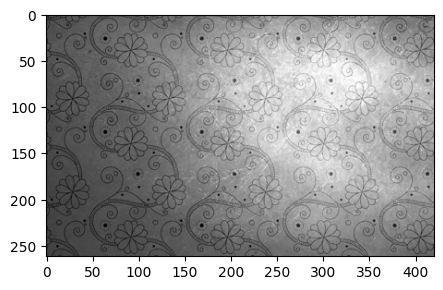

In [63]:
f = Image.open('im6.jpeg').convert('L')
h, w = f.size
f = f.resize((np.int64(h / 4), np.int64(w / 4)))
h, w = f.size
fig = plt.figure(figsize = (5,5))
plt.imshow(f, cmap='gray')
print(f.size)

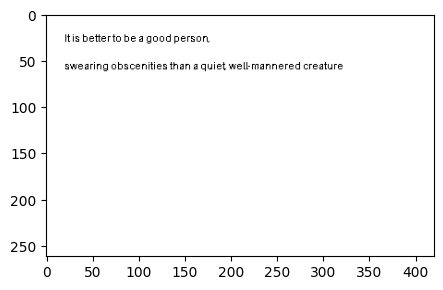

In [64]:
from PIL import ImageDraw
f_text = Image.fromarray(np.zeros((w, h)) + 255)
draw = ImageDraw.Draw(f_text)
draw.text((20, 20), "It is better to be a good person,")
draw.text((20, 50), "swearing obscenities than a quiet, well-mannered creature")
fig = plt.figure(figsize = (5,5))
plt.imshow(f_text, cmap='gray')

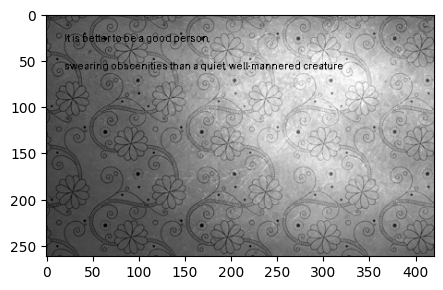

In [65]:
f = np.array(f)
P_Lambda = np.zeros((f.shape)) + 1
T = np.nonzero(np.array(f_text) < 255)
P_Lambda[T] = 0
Pf = P_Lambda * f
fig = plt.figure(figsize = (5,5))
plt.imshow(Pf, cmap='gray')

In [66]:
Epoch = 100
mu = 6
delta = 0.01
Level = 4
wavelet = 'db4'
u = Bregman_Lin(Pf, P_Lambda, Epoch, mu, Level, wavelet)

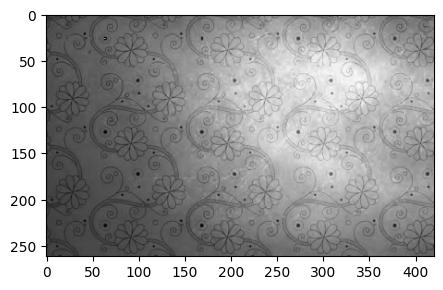

In [67]:
fig = plt.figure(figsize = (5,5))
plt.imshow(u, cmap='gray')